In [1]:
!pip install transformers datasets torch_cka huggingface_hub matplotlib seaborn tqdm bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import pickle
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from tqdm import tqdm
import re

In [ ]:
# Hugging Face login
from huggingface_hub import login
api_token = "hf-key"  # Replace with your Hugging Face API token
login(api_token)

# File paths
DATASET_PATH = '/content/drive/MyDrive/Hallucination/CALIBER-Final-256x4.csv'
OUTPUT_PATH = '/content/drive/MyDrive/Hallucination/caliber-llama_8b-output(1).csv'
CHECKPOINT_FILE = '/content/drive/MyDrive/Hallucination/caliber-llama_8b-checkpoint(1).pkl'

# Device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Initialize tokenizer and model
model_name = "meta-llama/Llama-3.1-8B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# Load dataset
df = pd.read_csv(DATASET_PATH)

def get_llama_answer(prompt_text):
    """
    Get answer from local Llama model
    """
    try:
        # Prepare the prompt with system message
        full_prompt = f"You are an assistant that answers only with the objective answer. Do not include any additional information.\n\nUser: {prompt_text}\n\nAssistant:"

        # Tokenize
        inputs = tokenizer(full_prompt, return_tensors="pt", truncation=True, max_length=512)
        inputs = inputs.to(device)

        # Generate
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=50,
                temperature=0.1,
                top_p=0.99,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )

        # Decode
        answer = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        return answer.strip()
    except Exception as e:
        print(f"Error processing prompt: {prompt_text}\nError: {e}")
        return ""

# Load checkpoint if available; otherwise initialize
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'rb') as f:
        checkpoint = pickle.load(f)
    start_index = checkpoint.get('current_index', 0)
    df['llama_answer_base'] = checkpoint.get('llama_answer_base', ["" for _ in range(len(df))])
    df['llama_answertype1'] = checkpoint.get('llama_answertype1', ["" for _ in range(len(df))])
    df['llama_answertype2'] = checkpoint.get('llama_answertype2', ["" for _ in range(len(df))])
    df['llama_answertype3'] = checkpoint.get('llama_answertype3', ["" for _ in range(len(df))])
    results_list = checkpoint.get('results_list', [])
    print(f"Resuming processing from row {start_index}")
else:
    start_index = 0
    df['llama_answer_base'] = ""
    df['llama_answertype1'] = ""
    df['llama_answertype2'] = ""
    df['llama_answertype3'] = ""
    results_list = []
    checkpoint = {
        'current_index': 0,
        'llama_answer_base': ["" for _ in range(len(df))],
        'llama_answertype1': ["" for _ in range(len(df))],
        'llama_answertype2': ["" for _ in range(len(df))],
        'llama_answertype3': ["" for _ in range(len(df))],
        'results_list': results_list,
    }
    print("Starting processing from the beginning...")

# Process each row with progress bar
for i in tqdm(range(start_index, len(df)), desc="Processing rows"):
    row = df.iloc[i]

    # Get prompts
    prompt_base = str(row['base_question'])
    prompt_type1 = str(row['type1'])
    prompt_type2 = str(row['type2'])
    prompt_type3 = str(row['type3'])

    # Get answers
    answer_base = get_llama_answer(prompt_base)
    answer_type1 = get_llama_answer(prompt_type1)
    answer_type2 = get_llama_answer(prompt_type2)
    answer_type3 = get_llama_answer(prompt_type3)

    # Save answers
    df.at[i, 'llama_answer_base'] = answer_base
    df.at[i, 'llama_answertype1'] = answer_type1
    df.at[i, 'llama_answertype2'] = answer_type2
    df.at[i, 'llama_answertype3'] = answer_type3

    # Update results list
    results_list.append({
        'row_index': i,
        'base_question': prompt_base,
        'llama_answer_base': answer_base,
        'type1': prompt_type1,
        'llama_answertype1': answer_type1,
        'type2': prompt_type2,
        'llama_answertype2': answer_type2,
        'type3': prompt_type3,
        'llama_answertype3': answer_type3
    })

    # Update checkpoint
    checkpoint['current_index'] = i + 1
    checkpoint['llama_answer_base'][i] = answer_base
    checkpoint['llama_answertype1'][i] = answer_type1
    checkpoint['llama_answertype2'][i] = answer_type2
    checkpoint['llama_answertype3'][i] = answer_type3
    checkpoint['results_list'] = results_list

    # Save checkpoint
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(checkpoint, f)

# Save final results
df.to_csv(OUTPUT_PATH, index=False)
print(f"Processing complete. Output saved to {OUTPUT_PATH}")

# Evaluation code
def normalize_text(text):
    """
    Normalizes text by converting to lowercase, removing punctuation,
    and standardizing whitespace.
    """
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Calculate accuracy
correct_base = correct_type1 = correct_type2 = correct_type3 = 0
total = len(df)

for index, row in df.iterrows():
    # Process ground truth
    ground_truth = str(row['ground_truth'])
    gt_answers = [normalize_text(ans) for ans in ground_truth.split(',')]
    gt_answers = [ans for ans in gt_answers if ans]

    # Process model answers
    answer_base = normalize_text(row['llama_answer_base'])
    answer_type1 = normalize_text(row['llama_answertype1'])
    answer_type2 = normalize_text(row['llama_answertype2'])
    answer_type3 = normalize_text(row['llama_answertype3'])

    # Update counters
    correct_base += answer_base in gt_answers if gt_answers else 0
    correct_type1 += answer_type1 in gt_answers if gt_answers else 0
    correct_type2 += answer_type2 in gt_answers if gt_answers else 0
    correct_type3 += answer_type3 in gt_answers if gt_answers else 0

# Print results
print("\nEvaluation Results:")
print(f"Base Answer Accuracy:   {(correct_base/total)*100:.2f}% ({correct_base}/{total})")
print(f"Type1 Answer Accuracy:  {(correct_type1/total)*100:.2f}% ({correct_type1}/{total})")
print(f"Type2 Answer Accuracy:  {(correct_type2/total)*100:.2f}% ({correct_type2}/{total})")
print(f"Type3 Answer Accuracy:  {(correct_type3/total)*100:.2f}% ({correct_type3}/{total})")

Starting processing from the beginning...


Processing rows: 100%|██████████| 256/256 [36:02<00:00,  8.45s/it]

Processing complete. Output saved to /content/drive/MyDrive/Hallucination/caliber-llama_8b-output(1).csv

Evaluation Results:
Base Answer Accuracy:   0.39% (1/256)
Type1 Answer Accuracy:  0.00% (0/256)
Type2 Answer Accuracy:  0.00% (0/256)
Type3 Answer Accuracy:  2.34% (6/256)


# cot

In [ ]:
import os
import pickle
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from tqdm import tqdm
import re

# Hugging Face login
from huggingface_hub import login
api_token = "hf-key"  # Replace with your Hugging Face API token
login(api_token)

# File paths
DATASET_PATH = '/content/drive/MyDrive/Hallucination/CALIBER-Final-256x4.csv'
OUTPUT_PATH = '/content/drive/MyDrive/Hallucination/caliber-llama_8b-COT.csv'
CHECKPOINT_FILE = '/content/drive/MyDrive/Hallucination/caliber-llama_8b-checkpoint-COT.pkl'

# Device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Initialize tokenizer and model
model_name = "meta-llama/Llama-3.1-8B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# Load dataset
df = pd.read_csv(DATASET_PATH)

import pandas as pd
import torch
import pickle
import os
import re
from tqdm import tqdm

def get_llama_answer(prompt_text):
    """
    Get answer from local Llama model with Chain of Thought reasoning
    """
    try:
        # Prepare the prompt with system message and CoT instructions
        cot_prompt = "You are an expert at answering complex and obfuscated objective type questions. Think step by step to deconstruct the question, identify the core information needed, and derive the correct answer. Finally, state the answer clearly and concisely. Follow these steps:1. Read the entire question carefully, even if it includes extra indirection or distractors.2. Isolate the core query by stripping away any added layers of indirection, irrelevant details,or red herrings. 3. Reverse any transformations to recover the original meaning of the question. 4. Apply logical reasoning and your domain knowledge to determine the correct answer. 5. Finally, output only the concise final answer without showing any internal reasoning or extra text."

        full_prompt = cot_prompt.format(question=prompt_text)

        # Tokenize with increased max length to accommodate CoT
        inputs = tokenizer(full_prompt, return_tensors="pt", truncation=True, max_length=1024)
        inputs = inputs.to(device)

        # Generate with adjusted parameters for CoT
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=200,  # Increased to accommodate reasoning steps
                temperature=0.1,
                top_p=0.99,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )

        # Decode and extract final answer
        full_response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

        # Extract only the final answer after "Therefore, the answer is:"
        try:
            final_answer = full_response.split("Therefore, the answer is:")[-1].strip()
        except:
            final_answer = full_response.strip()

        return final_answer
    except Exception as e:
        print(f"Error processing prompt: {prompt_text}\nError: {e}")
        return ""

# Load checkpoint if available; otherwise initialize
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'rb') as f:
        checkpoint = pickle.load(f)
    start_index = checkpoint.get('current_index', 0)
    df['llama_answer_base'] = checkpoint.get('llama_answer_base', ["" for _ in range(len(df))])
    df['llama_answertype1'] = checkpoint.get('llama_answertype1', ["" for _ in range(len(df))])
    df['llama_answertype2'] = checkpoint.get('llama_answertype2', ["" for _ in range(len(df))])
    df['llama_answertype3'] = checkpoint.get('llama_answertype3', ["" for _ in range(len(df))])
    results_list = checkpoint.get('results_list', [])
    print(f"Resuming processing from row {start_index}")
else:
    start_index = 0
    df['llama_answer_base'] = ""
    df['llama_answertype1'] = ""
    df['llama_answertype2'] = ""
    df['llama_answertype3'] = ""
    results_list = []
    checkpoint = {
        'current_index': 0,
        'llama_answer_base': ["" for _ in range(len(df))],
        'llama_answertype1': ["" for _ in range(len(df))],
        'llama_answertype2': ["" for _ in range(len(df))],
        'llama_answertype3': ["" for _ in range(len(df))],
        'results_list': results_list,
    }
    print("Starting processing from the beginning...")

# Process each row with progress bar
for i in tqdm(range(start_index, len(df)), desc="Processing rows"):
    row = df.iloc[i]

    # Get prompts
    prompt_base = str(row['base_question'])
    prompt_type1 = str(row['type1'])
    prompt_type2 = str(row['type2'])
    prompt_type3 = str(row['type3'])

    # Get answers using CoT reasoning
    answer_base = get_llama_answer(prompt_base)
    answer_type1 = get_llama_answer(prompt_type1)
    answer_type2 = get_llama_answer(prompt_type2)
    answer_type3 = get_llama_answer(prompt_type3)

    # Save answers
    df.at[i, 'llama_answer_base'] = answer_base
    df.at[i, 'llama_answertype1'] = answer_type1
    df.at[i, 'llama_answertype2'] = answer_type2
    df.at[i, 'llama_answertype3'] = answer_type3

    # Update results list with full context
    results_list.append({
        'row_index': i,
        'base_question': prompt_base,
        'llama_answer_base': answer_base,
        'type1': prompt_type1,
        'llama_answertype1': answer_type1,
        'type2': prompt_type2,
        'llama_answertype2': answer_type2,
        'type3': prompt_type3,
        'llama_answertype3': answer_type3
    })

    # Update checkpoint
    checkpoint['current_index'] = i + 1
    checkpoint['llama_answer_base'][i] = answer_base
    checkpoint['llama_answertype1'][i] = answer_type1
    checkpoint['llama_answertype2'][i] = answer_type2
    checkpoint['llama_answertype3'][i] = answer_type3
    checkpoint['results_list'] = results_list

    # Save checkpoint
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(checkpoint, f)

# Save final results
df.to_csv(OUTPUT_PATH, index=False)
print(f"Processing complete. Output saved to {OUTPUT_PATH}")

# Evaluation code remains the same
def normalize_text(text):
    """
    Normalizes text by converting to lowercase, removing punctuation,
    and standardizing whitespace.
    """
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Calculate accuracy
correct_base = correct_type1 = correct_type2 = correct_type3 = 0
total = len(df)

for index, row in df.iterrows():
    # Process ground truth
    ground_truth = str(row['ground_truth'])
    gt_answers = [normalize_text(ans) for ans in ground_truth.split(',')]
    gt_answers = [ans for ans in gt_answers if ans]

    # Process model answers
    answer_base = normalize_text(row['llama_answer_base'])
    answer_type1 = normalize_text(row['llama_answertype1'])
    answer_type2 = normalize_text(row['llama_answertype2'])
    answer_type3 = normalize_text(row['llama_answertype3'])

    # Update counters
    correct_base += any(gt in answer_base for gt in gt_answers) if gt_answers else 0
    correct_type1 += any(gt in answer_type1 for gt in gt_answers) if gt_answers else 0
    correct_type2 += any(gt in answer_type2 for gt in gt_answers) if gt_answers else 0
    correct_type3 += any(gt in answer_type3 for gt in gt_answers) if gt_answers else 0

# Print results
print("\nEvaluation Results:")
print(f"Base Answer Accuracy:   {(correct_base/total)*100:.2f}% ({correct_base}/{total})")
print(f"Type1 Answer Accuracy:  {(correct_type1/total)*100:.2f}% ({correct_type1}/{total})")
print(f"Type2 Answer Accuracy:  {(correct_type2/total)*100:.2f}% ({correct_type2}/{total})")
print(f"Type3 Answer Accuracy:  {(correct_type3/total)*100:.2f}% ({correct_type3}/{total})")

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Starting processing from the beginning...


Processing rows: 100%|██████████| 256/256 [1:38:51<00:00, 23.17s/it]

Processing complete. Output saved to /content/drive/MyDrive/Hallucination/caliber-llama_8b-COT.csv

Evaluation Results:
Base Answer Accuracy:   3.91% (10/256)
Type1 Answer Accuracy:  5.47% (14/256)
Type2 Answer Accuracy:  4.69% (12/256)
Type3 Answer Accuracy:  5.86% (15/256)


# probing


Using device: cuda


/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:818: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]


Query: What is the capital of Australia?
Model answer: Answer: Canberra.
Matches gold standard: False


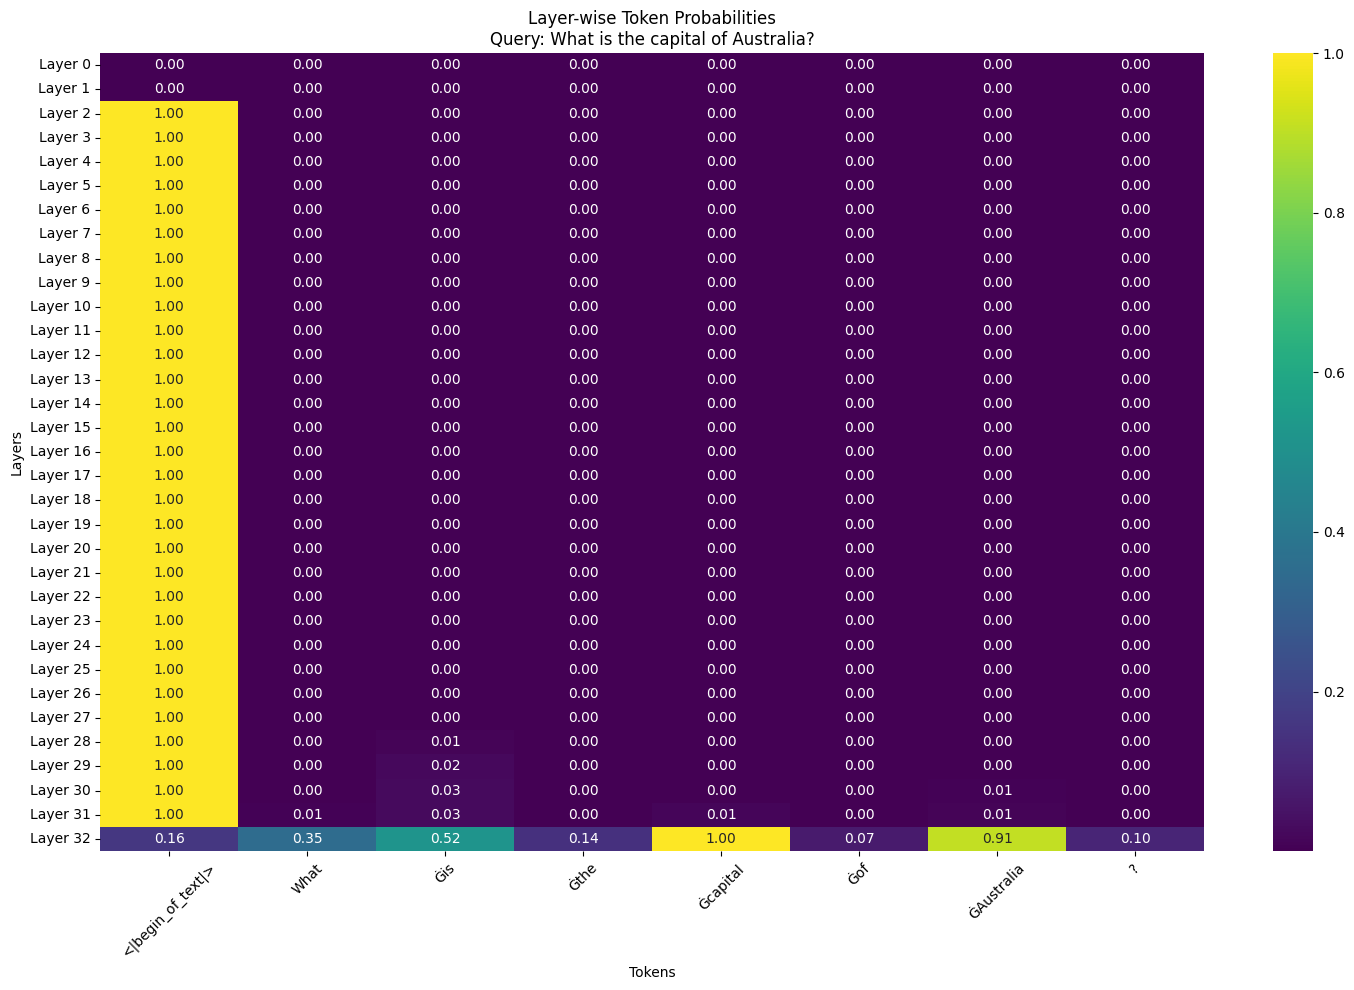


Query: Which urban center, situated within the Commonwealth realm that witnessed the dawning of the new millennium with a quadrennial celebration of athletic prowess, serves as the locus of governance for a continent-spanning island nation, characterized by its distinctive fauna and a political system shaped by the Westminster tradition?
Model answer: Answer: The urban center in question is Sydney, located in Australia, which hosted the 2000 Summer Olympics. Australia is an island nation in the Southern Hemisphere, known for its unique wildlife and political system based on the Westminster model.
Matches gold standard: False


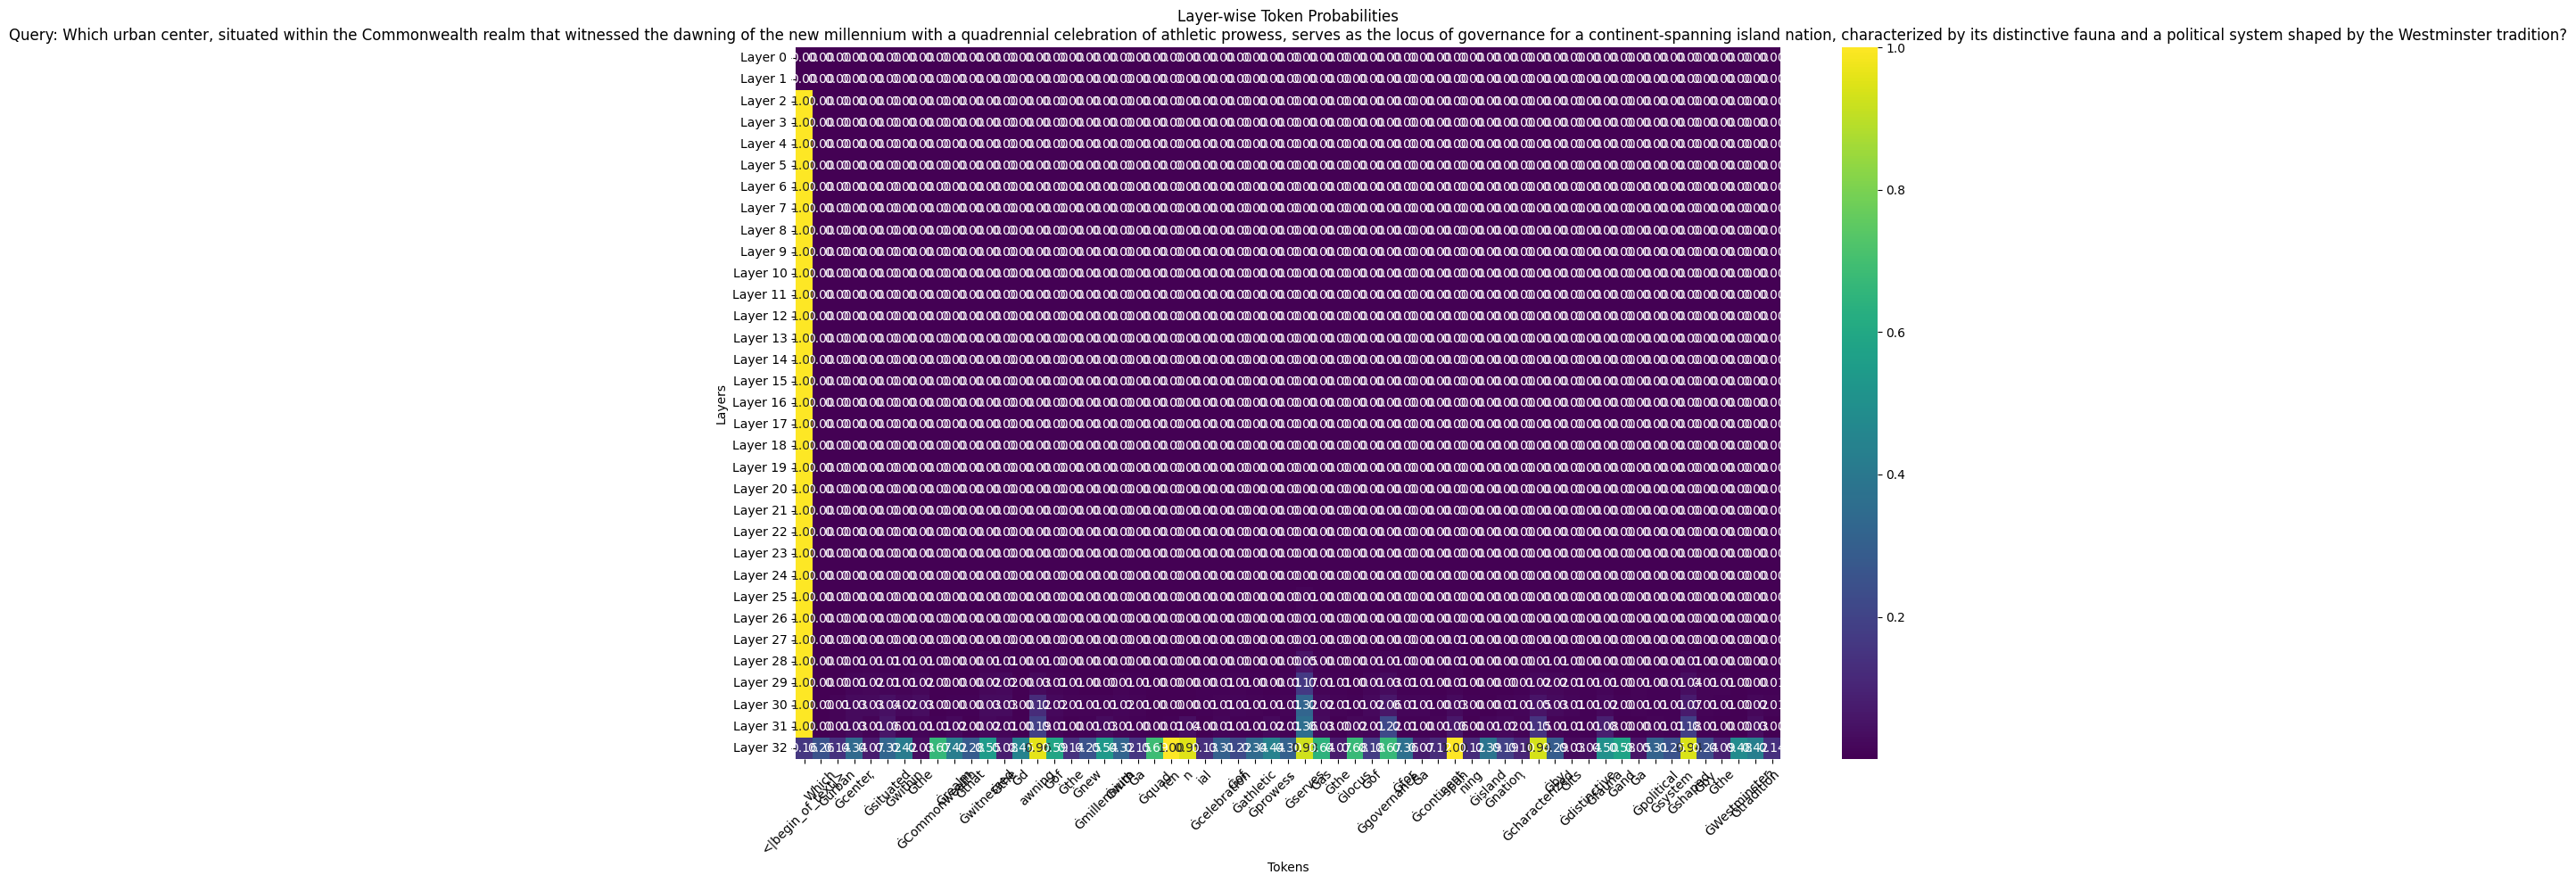


Query: Amidst ongoing debates about regional development, and considering the political and administrative heart of the land Down Under, is the principal federal city—which we'll call X—more populous than the metropolis that annually celebrates equestrian prowess, or does it rival the city that serves as the harbour and is also known for an architectural marvel in terms of size? By what name, then, is this city designated on official maps?
Model answer: Answer: The city that annually celebrates equestrian prowess is Melbourne, which is more populous than the metropolis that serves as the harbour, which is Sydney. The city that serves as the harbour is also known for an architectural marvel in terms of size
Matches gold standard: False


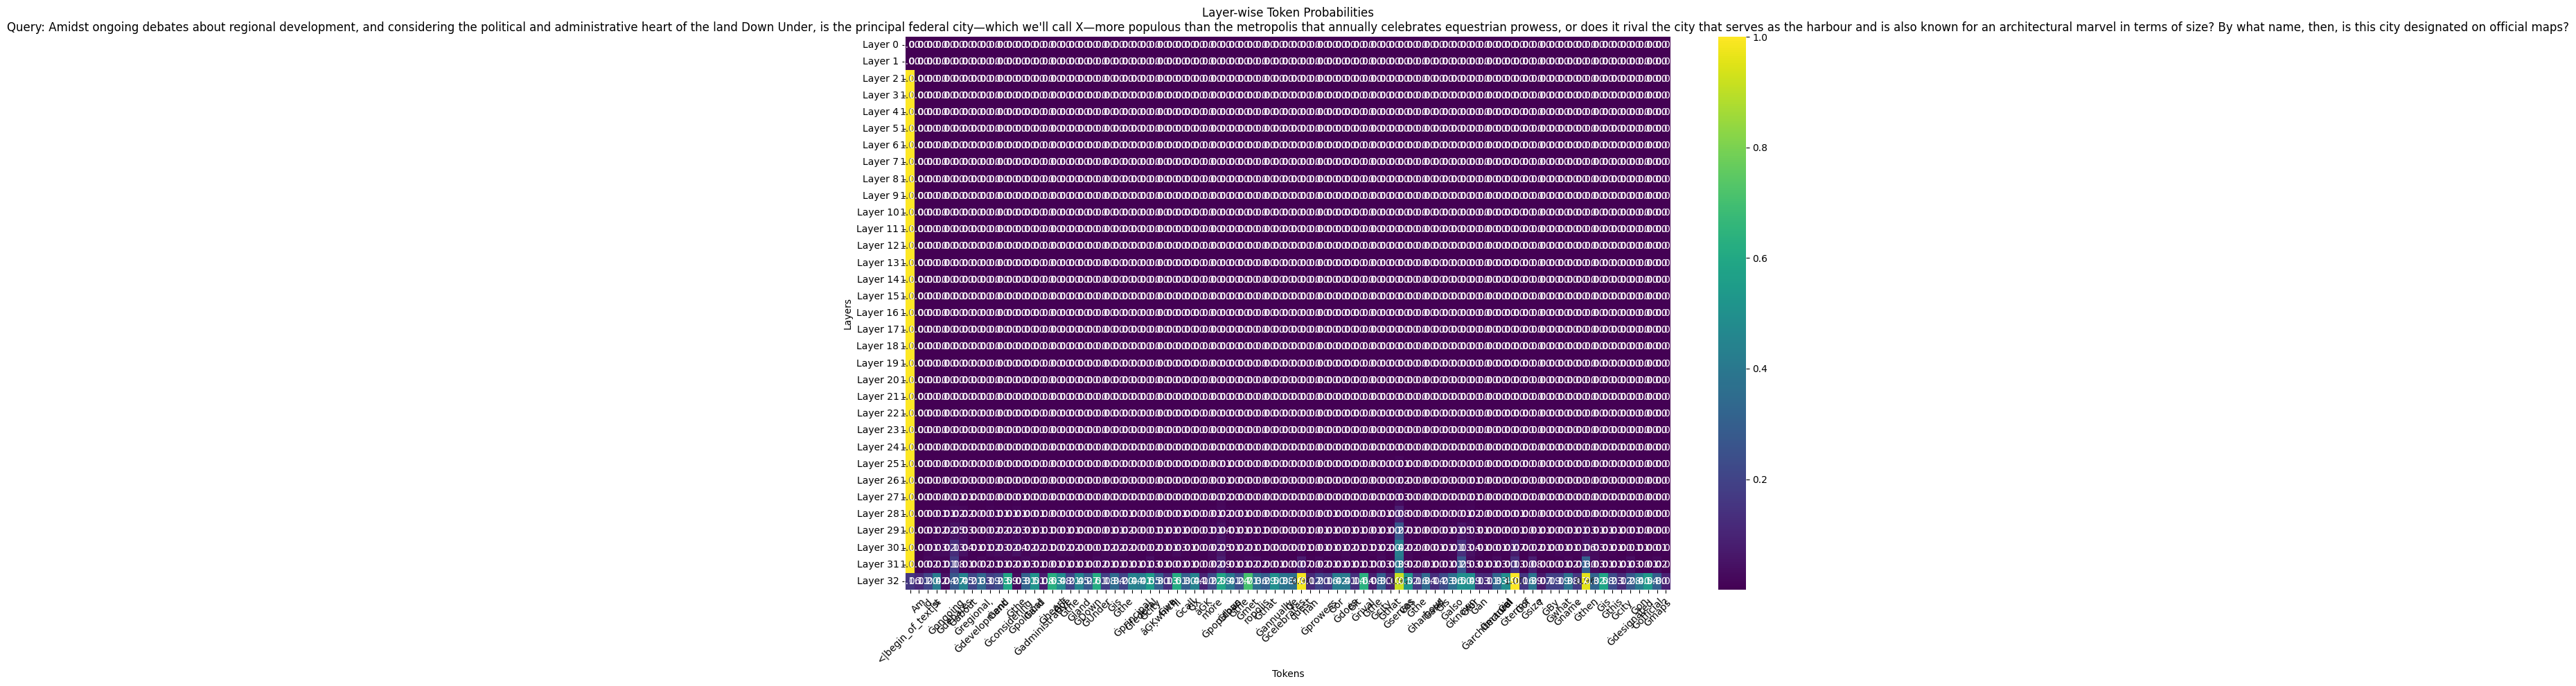


Query: Amidst the echoes of the Great Emu War and the ongoing debate over the Pavlova's true origins, can you identify the city, nestled within the Australian Capital Territory, that serves as the seat of the Governor-General, currently held by the King's representative, and where the Old Parliament House, a relic of the era before self-government was fully realized and a structure often mistaken for the primary legislative building due to its prominent position near Lake Burley Griffin, is located, remembering that the nation's highest court is actually located elsewhere? Furthermore, disregard the spurious claims that Sydney or Melbourne hold this distinction, as they are merely the most populous and historically significant metropolises, respectively.
Model answer: 
Matches gold standard: False


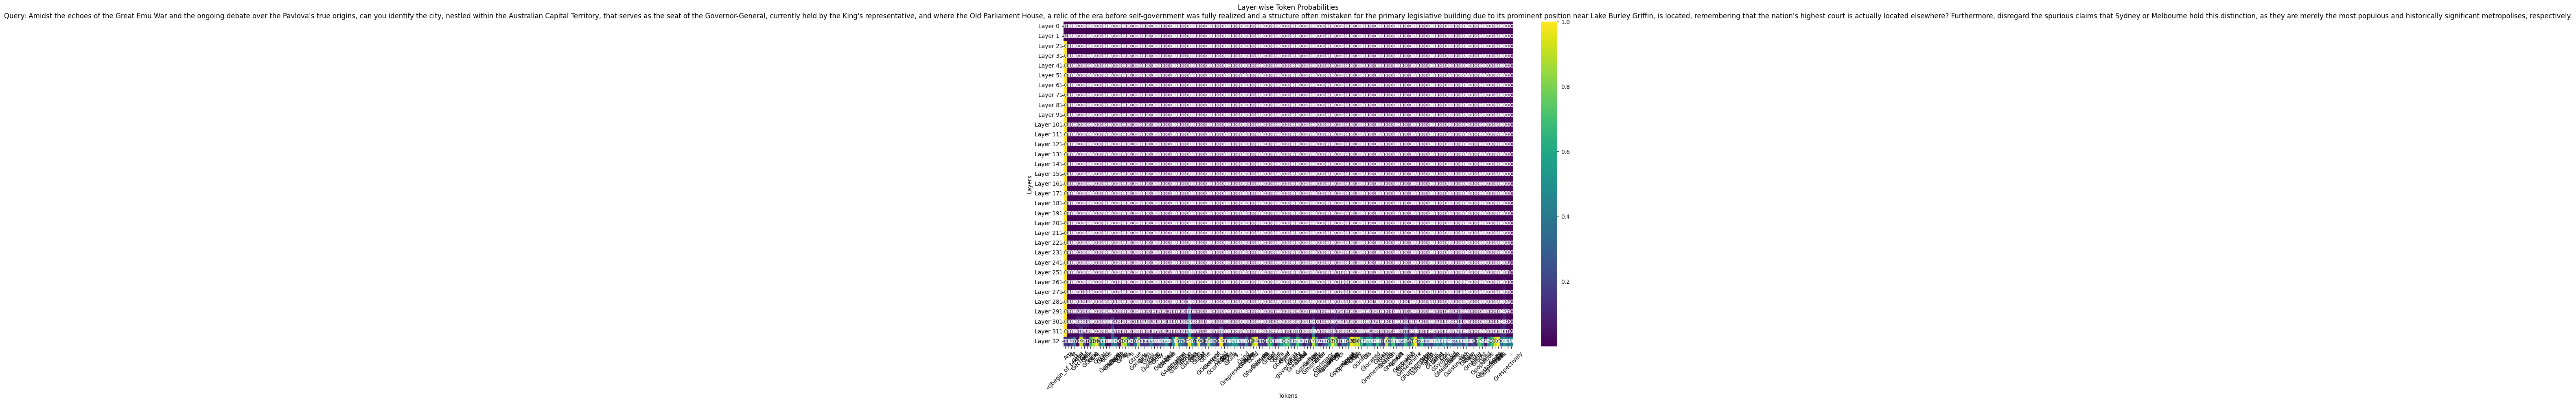

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from huggingface_hub import login

def get_layer_wise_probabilities(model, tokenizer, query, device):
    """Get token probabilities for each layer"""
    inputs = tokenizer(query, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    hidden_states = outputs.hidden_states
    num_layers = len(hidden_states)

    layer_probs = []
    for layer_idx in range(num_layers):
        layer_hidden = hidden_states[layer_idx]

        if hasattr(model, 'lm_head'):
            try:
                layer_logits = model.lm_head(layer_hidden)
                layer_logits = layer_logits.detach()
                layer_probs.append(torch.softmax(layer_logits, dim=-1))
            except Exception as e:
                layer_probs.append(None)
        else:
            layer_probs.append(None)

    return inputs["input_ids"][0].detach(), layer_probs

def plot_layer_wise_analysis(tokenizer, query, token_ids, layer_probs):
    """Plot layer-wise token probability analysis"""
    tokens = tokenizer.convert_ids_to_tokens(token_ids)
    valid_probs = [p for p in layer_probs if p is not None]
    num_layers = len(valid_probs)
    num_tokens = len(tokens)

    if num_layers == 0:
        return None

    heatmap_data = np.zeros((num_layers, num_tokens))
    for layer_idx, layer_prob in enumerate(valid_probs):
        token_probs = torch.max(layer_prob[0].detach(), dim=1).values.cpu().numpy()
        heatmap_data[layer_idx] = token_probs

    plt.figure(figsize=(15, 10))
    sns.heatmap(heatmap_data,
                xticklabels=tokens,
                yticklabels=[f"Layer {i}" for i in range(num_layers)],
                cmap="viridis",
                annot=True,
                fmt=".2f")
    plt.title(f"Layer-wise Token Probabilities\nQuery: {query}")
    plt.xlabel("Tokens")
    plt.ylabel("Layers")
    plt.xticks(rotation=45)
    plt.tight_layout()
    return plt.gcf()

def get_llama_answer(model, tokenizer, prompt_text, device):
    """Get answer from Llama model"""
    try:
        # Modified prompt to be more explicit about the format
        full_prompt = (
            "Provide only the direct answer without any additional text or conversation format. "
            "Do not include 'User:', 'Assistant:', or any other prefixes. "
            f"Question: {prompt_text}"
        )

        inputs = tokenizer(full_prompt, return_tensors="pt", truncation=True, max_length=512)
        inputs = inputs.to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=50,
                temperature=0.1,
                top_p=0.99,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )

        # Get only the generated answer part
        input_length = inputs['input_ids'].shape[1]
        answer_tokens = outputs[0][input_length:]
        answer = tokenizer.decode(answer_tokens, skip_special_tokens=True)

        # Clean up the answer by removing any conversation artifacts
        answer = answer.replace("User:", "").replace("Assistant:", "").strip()
        if "Question:" in answer:
            answer = answer.split("Question:")[0].strip()

        return answer
    except Exception as e:
        print(f"Error processing prompt: {prompt_text}\nError: {e}")
        return ""

def analyze_query(model, tokenizer, query, gold_standard=None, device="cuda", show_plot=True):
    """Perform analysis for a single query"""
    print(f"\nQuery: {query}")

    # Get model answer
    answer = get_llama_answer(model, tokenizer, query, device)
    print(f"Model answer: {answer}")
    if gold_standard:
        matches = answer.lower().strip() == gold_standard.lower().strip()
        print(f"Matches gold standard: {matches}")

    if show_plot:
        # Get layer-wise probabilities and plot
        token_ids, layer_probs = get_layer_wise_probabilities(model, tokenizer, query, device)
        fig = plot_layer_wise_analysis(tokenizer, query, token_ids, layer_probs)
        if fig:
            plt.show()

# Main execution
if __name__ == "__main__":
    # Device configuration
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Configure 4-bit quantization
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16
    )

    # Initialize tokenizer and model
    model_name = "meta-llama/Llama-3.1-8B"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
        output_hidden_states=True
    )

    # Example queries
    queries = [
        "What is the capital of Australia?",
        "Which urban center, situated within the Commonwealth realm that witnessed the dawning of the new millennium with a quadrennial celebration of athletic prowess, serves as the locus of governance for a continent-spanning island nation, characterized by its distinctive fauna and a political system shaped by the Westminster tradition?",
        "Amidst ongoing debates about regional development, and considering the political and administrative heart of the land Down Under, is the principal federal city—which we'll call X—more populous than the metropolis that annually celebrates equestrian prowess, or does it rival the city that serves as the harbour and is also known for an architectural marvel in terms of size? By what name, then, is this city designated on official maps?",
        "Amidst the echoes of the Great Emu War and the ongoing debate over the Pavlova's true origins, can you identify the city, nestled within the Australian Capital Territory, that serves as the seat of the Governor-General, currently held by the King's representative, and where the Old Parliament House, a relic of the era before self-government was fully realized and a structure often mistaken for the primary legislative building due to its prominent position near Lake Burley Griffin, is located, remembering that the nation's highest court is actually located elsewhere? Furthermore, disregard the spurious claims that Sydney or Melbourne hold this distinction, as they are merely the most populous and historically significant metropolises, respectively."
    ]

    gold_standard = "Canberra"

    # Analyze each query
    for query in queries:
        analyze_query(model, tokenizer, query, gold_standard, device, show_plot=True)